# NBA Player Value Analysis (2021–2026)
**Author:** Renard Pascual

A six-season analysis of NBA player performance data built for a fictional Western
Conference franchise's analytics department. The analysis spans four sections:
league-wide trend analysis, player archetype clustering, contract value regression,
and breakout candidate classification.

**Data Sources:** Basketball Reference (advanced stats, per game stats, 2026 salaries),
HoopsHype (salaries 2021–2025)

**Master Dataset:** `cleaned/master_final.csv` — 2,068 rows x 64 columns

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, classification_report

In [2]:
# Load master dataset
master_final = pd.read_csv("cleaned/master_final.csv")
 
# Global style settings
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.family"] = "sans-serif"
 
os.makedirs("images", exist_ok=True)
 
print(f"Dataset loaded: {master_final.shape[0]:,} rows, {master_final.shape[1]} columns")
print(f"Seasons: {sorted(master_final['season'].unique())}")
print(f"Unique players: {master_final['Player'].nunique():,}")

Dataset loaded: 2,068 rows, 64 columns
Seasons: [2021, 2022, 2023, 2024, 2025, 2026]
Unique players: 623


## Section 1 — League Landscape (2021–2026)

Establishing the analytical context by examining how the NBA has structurally changed across six seasons. These trends form the baseline for evaluating individual player value in later sections.

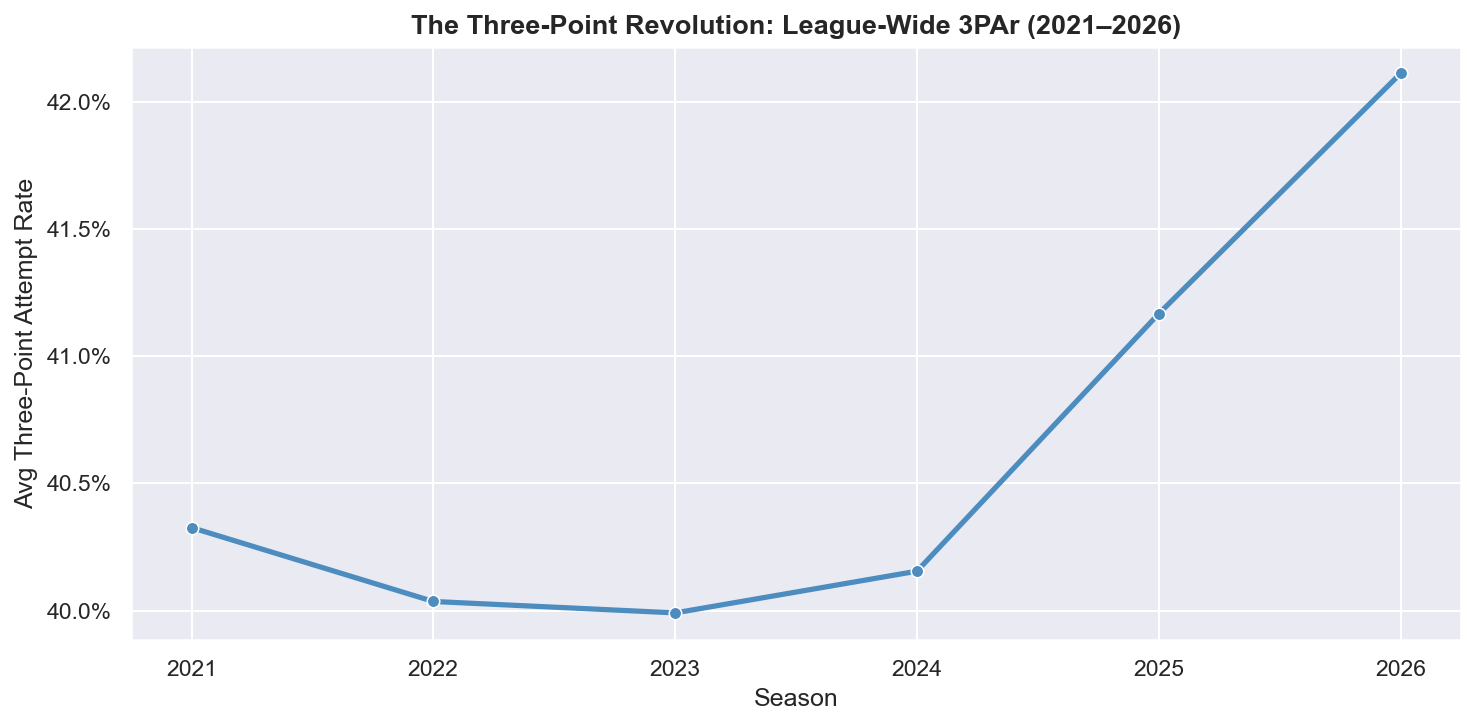

In [3]:
# Chart 1: League-Wide 3-Point Attempt Rate Over Time
league_3par = master_final.groupby("season")["3PAr"].mean().reset_index()
 
fig, ax = plt.subplots()
sns.lineplot(data=league_3par, x="season", y="3PAr",
             marker="o", linewidth=2.5, color="#4C8CBF", ax=ax)
ax.set_title("The Three-Point Revolution: League-Wide 3PAr (2021–2026)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Season")
ax.set_ylabel("Avg Three-Point Attempt Rate")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.tight_layout()
plt.savefig("images/league_3par_trend.png")
plt.show()

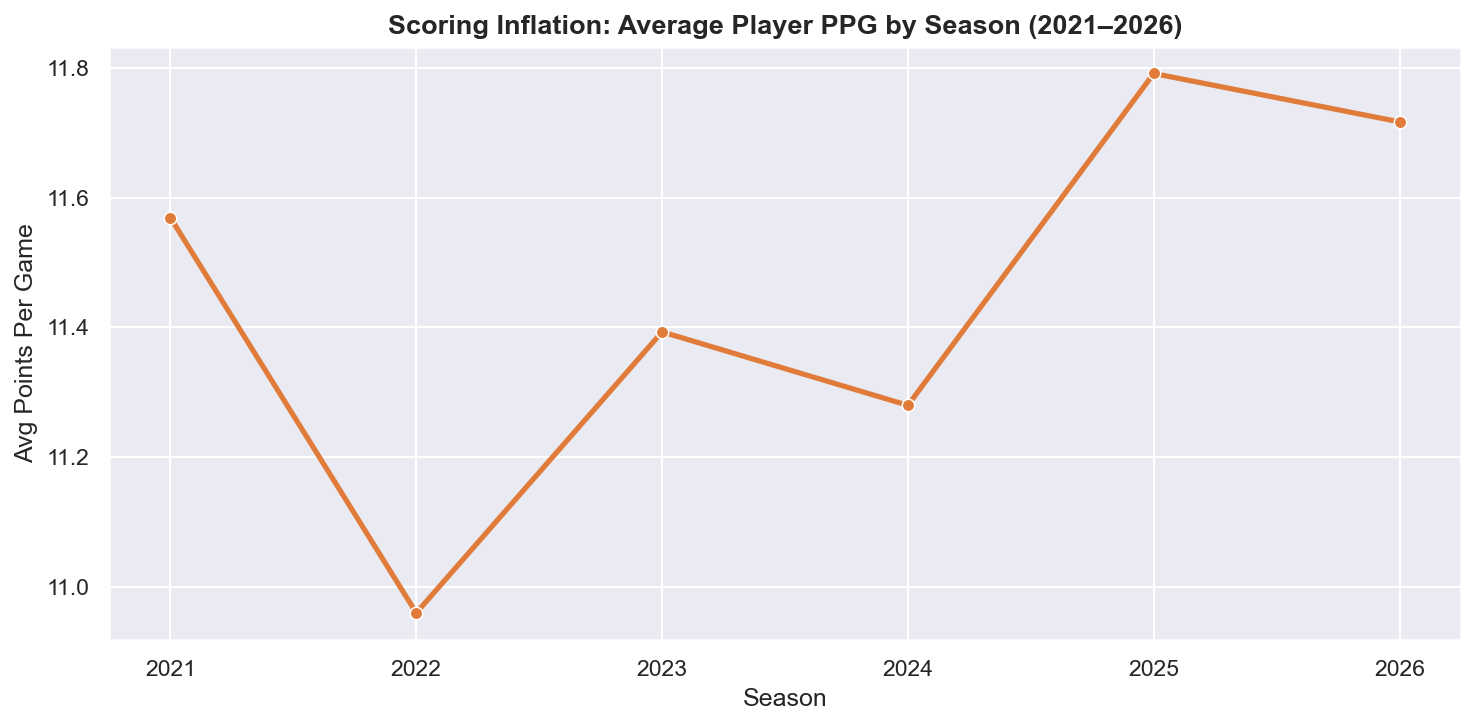

In [4]:
# Chart 2: Scoring Inflation — Avg Player PPG by Season
scoring_trends = master_final.groupby("season")["PTS"].mean().reset_index()
 
fig, ax = plt.subplots()
sns.lineplot(data=scoring_trends, x="season", y="PTS",
             marker="o", linewidth=2.5, color="#E07B39", ax=ax)
ax.set_title("Scoring Inflation: Average Player PPG by Season (2021–2026)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Season")
ax.set_ylabel("Avg Points Per Game")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}"))
plt.tight_layout()
plt.savefig("images/scoring_inflation.png")
plt.show()

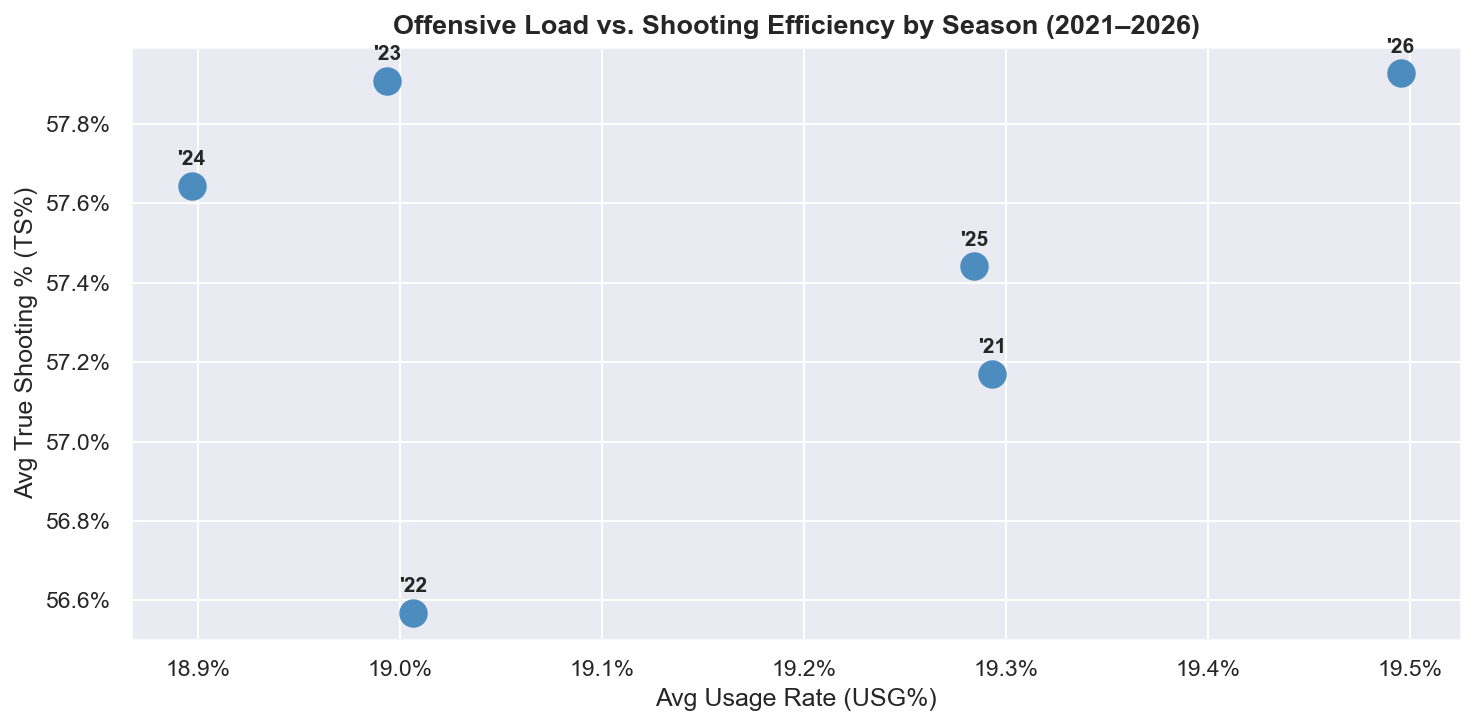

In [5]:
# Chart 3: Offensive Load vs. Shooting Efficiency by Season
load_eff = master_final.groupby("season")[["USG%", "TS%"]].mean().reset_index()
 
fig, ax = plt.subplots()
for i, row in load_eff.iterrows():
    ax.scatter(row["USG%"], row["TS%"], color="#4C8CBF", s=160, zorder=5)
    ax.annotate(f"'{str(int(row['season']))[2:]}",
                xy=(row["USG%"], row["TS%"]),
                xytext=(0, 10), textcoords="offset points",
                fontsize=10, fontweight="bold", ha="center")
 
ax.set_title("Offensive Load vs. Shooting Efficiency by Season (2021–2026)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Avg Usage Rate (USG%)")
ax.set_ylabel("Avg True Shooting % (TS%)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.tight_layout()
plt.savefig("images/load_vs_efficiency.png")
plt.show()

/var/folders/d0/2zghwmw96y3dhmr3z4r984m80000gn/T/ipykernel_39647/1369802194.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pos, x="Pos_adv", y="USG%",


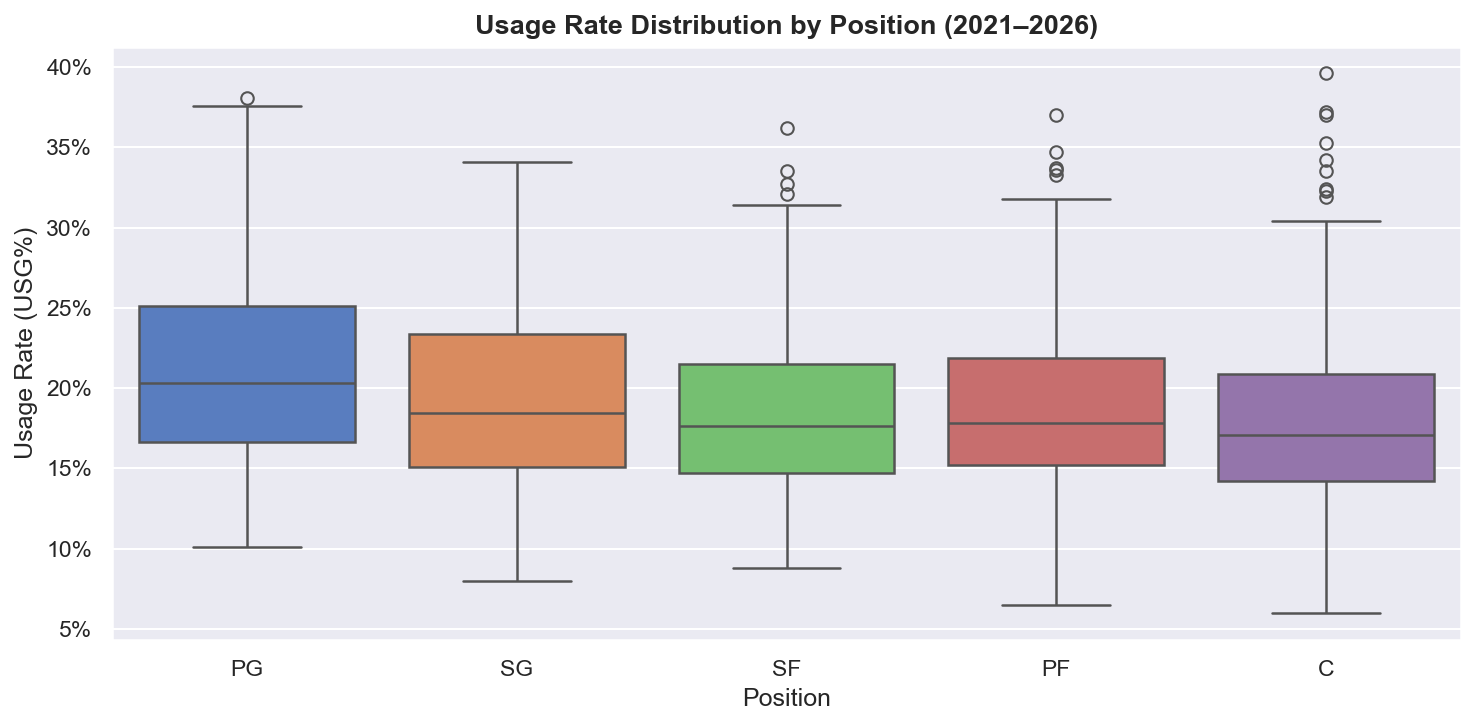

In [6]:
# Chart 4: Usage Rate Distribution by Position
standard_positions = ["PG", "SG", "SF", "PF", "C"]
df_pos = master_final[master_final["Pos_adv"].isin(standard_positions)]
 
fig, ax = plt.subplots()
sns.boxplot(data=df_pos, x="Pos_adv", y="USG%",
            order=standard_positions, palette="muted", linewidth=1.2, ax=ax)
ax.set_title("Usage Rate Distribution by Position (2021–2026)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Position")
ax.set_ylabel("Usage Rate (USG%)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))
plt.tight_layout()
plt.savefig("images/usg_by_position.png")
plt.show()

## Section 2 — Defining the Modern NBA Player

KMeans clustering on eight advanced metrics to group 2,068 player-seasons into six meaningful archetypes. Moving beyond traditional position labels to capture what players actually do on the floor.

In [7]:
# Feature selection and scaling
cluster_features = ["USG%", "TS%", "3PAr", "AST%", "TRB%", "STL%", "BLK%", "BPM"]
 
df_cluster = master_final[cluster_features].dropna()
cluster_index = df_cluster.index
 
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(df_cluster)
 
print(f"Clustering on {len(df_cluster):,} player-seasons across {len(cluster_features)} features")

Clustering on 2,068 player-seasons across 8 features


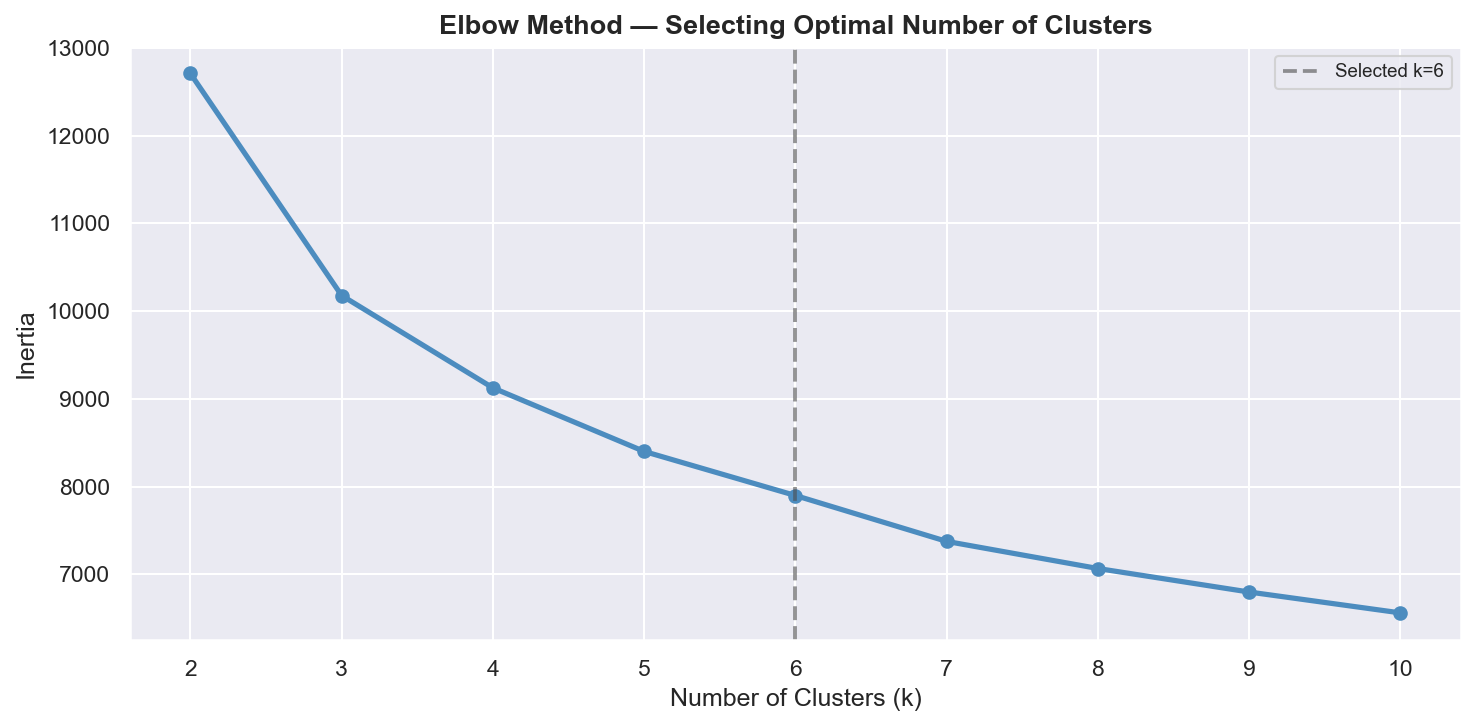

In [8]:
# Chart 5: Elbow Method — Selecting Optimal k
inertias = []
k_range = range(2, 11)
 
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
 
fig, ax = plt.subplots()
ax.plot(k_range, inertias, marker="o", linewidth=2.5, color="#4C8CBF")
ax.axvline(6, color="#4D4D4D", linewidth=1.8, linestyle="--", alpha=0.6, label="Selected k=6")
ax.set_title("Elbow Method — Selecting Optimal Number of Clusters",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("images/elbow_chart.png")
plt.show()

In [9]:
# Fit KMeans with k=6
km = KMeans(n_clusters=6, random_state=42, n_init=10)
km.fit(X_scaled)
 
master_final.loc[cluster_index, "Cluster"] = km.labels_
master_final["Cluster"] = master_final["Cluster"].astype("Int64")
 
# Assign archetype labels based on cluster profiles
cluster_labels = {
    0: "Defensive Connectors",
    1: "Versatile Bigs",
    2: "Offensive Engines",
    3: "Floor Spacers",
    4: "Volume Scorers",
    5: "Rim Anchors"
}
 
master_final["Archetype"] = master_final["Cluster"].map(cluster_labels)
 
print("Archetype distribution:")
print(master_final["Archetype"].value_counts().to_string())

Archetype distribution:
Archetype
Floor Spacers           482
Volume Scorers          425
Offensive Engines       346
Versatile Bigs          309
Defensive Connectors    279
Rim Anchors             227


In [10]:
# Archetype color palette — consistent across all Section 2+ charts
archetype_colors = {
    "Offensive Engines":     "#4C8CBF",
    "Rim Anchors":           "#E07B39",
    "Versatile Bigs":        "#4CAF7D",
    "Floor Spacers":         "#C75B7A",
    "Defensive Connectors":  "#8B6BB1",
    "Volume Scorers":        "#A0845C"
}
 
archetype_order = [
    "Offensive Engines", "Rim Anchors", "Versatile Bigs",
    "Floor Spacers", "Defensive Connectors", "Volume Scorers"
]

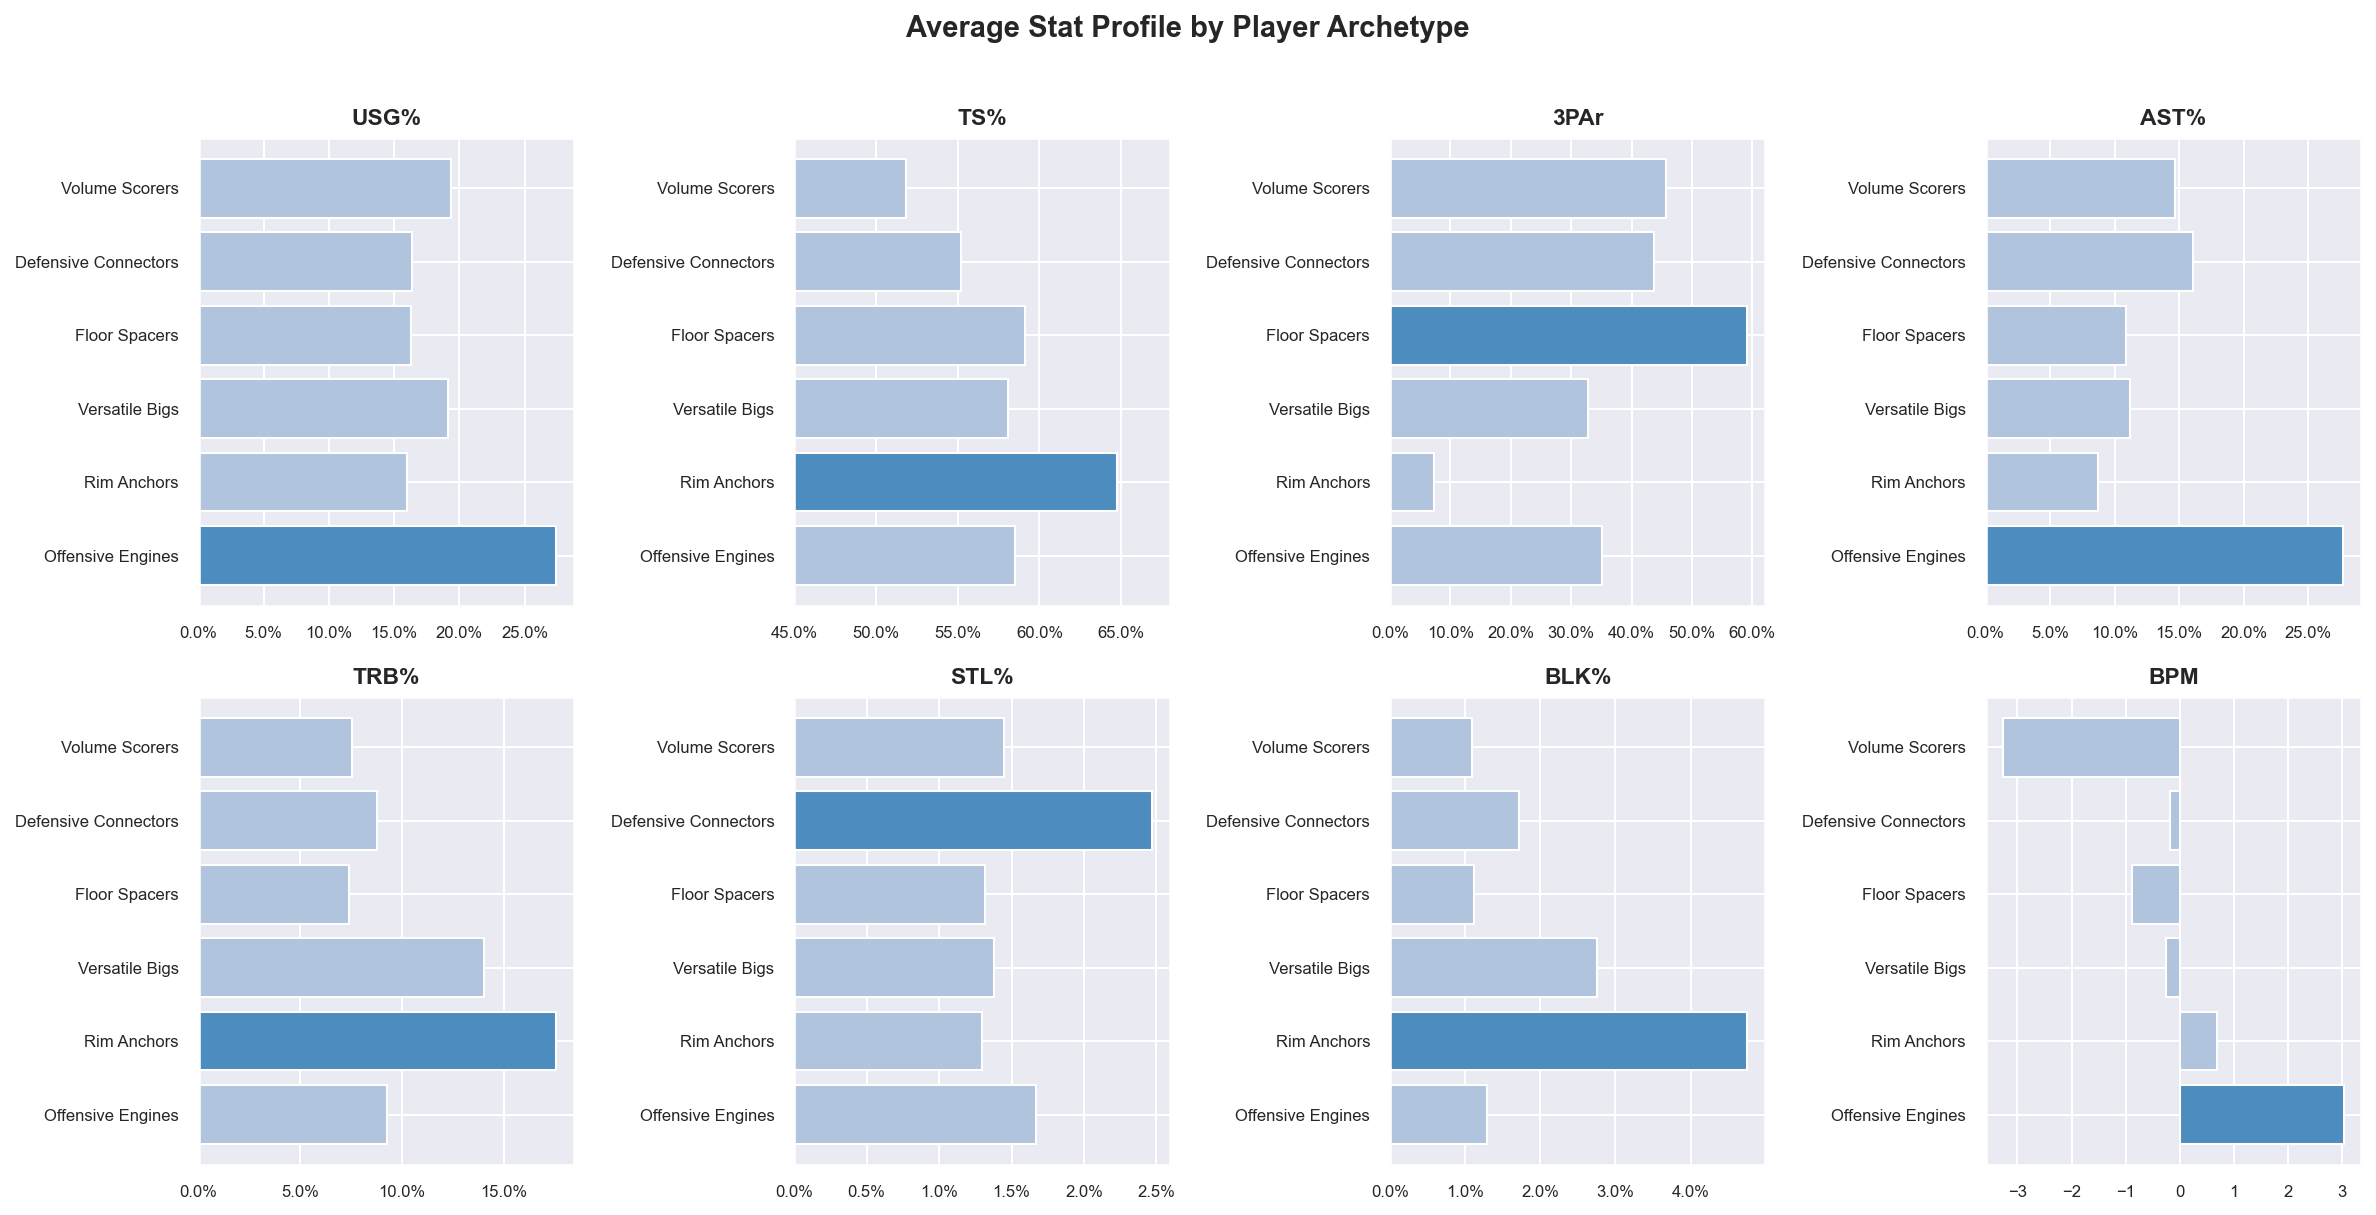

In [11]:
# Chart 6: Average Stat Profile by Archetype (8-panel bar chart)
profile_features = ["USG%", "TS%", "3PAr", "AST%", "TRB%", "STL%", "BLK%", "BPM"]
profile = (master_final.groupby("Archetype")[profile_features]
           .mean()
           .loc[archetype_order])
 
fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=150)
axes = axes.flatten()
 
for i, feat in enumerate(profile_features):
    ax = axes[i]
    values = profile[feat]
    colors = ["#4C8CBF" if v == values.max() else "#B0C4DE" for v in values]
    ax.barh(archetype_order, values, color=colors)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=8)
    if feat in ["TS%", "3PAr"]:
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1%}"))
    elif feat in ["USG%", "AST%", "TRB%", "STL%", "BLK%"]:
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}%"))
    if feat == "TS%":
        ax.set_xlim(left=0.45)
 
fig.suptitle("Average Stat Profile by Player Archetype",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("images/archetype_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/d0/2zghwmw96y3dhmr3z4r984m80000gn/T/ipykernel_39647/1240434477.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_final, x="Archetype", y="BPM",


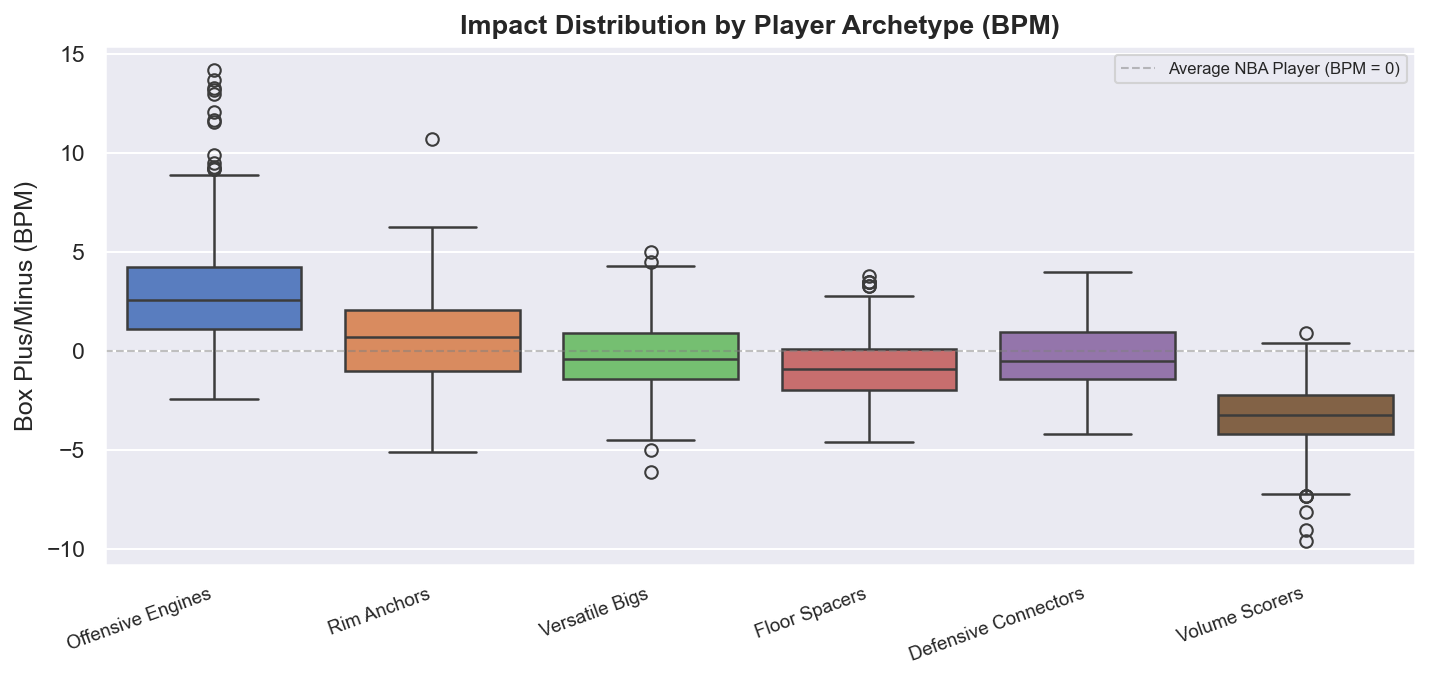

In [12]:
# Chart 7: BPM Distribution by Archetype
fig, ax = plt.subplots()
sns.boxplot(data=master_final, x="Archetype", y="BPM",
            order=archetype_order, palette="muted", linewidth=1.2, ax=ax)
ax.axhline(0, color="#808080", linewidth=1.0, linestyle="--", alpha=0.5, label="Average NBA Player (BPM = 0)")
ax.set_title("Impact Distribution by Player Archetype (BPM)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Box Plus/Minus (BPM)")
ax.legend(fontsize=8)
plt.xticks(rotation=20, ha="right", fontsize=9)
plt.tight_layout(pad=2.0)
plt.savefig("images/bpm_by_archetype.png")
plt.show()

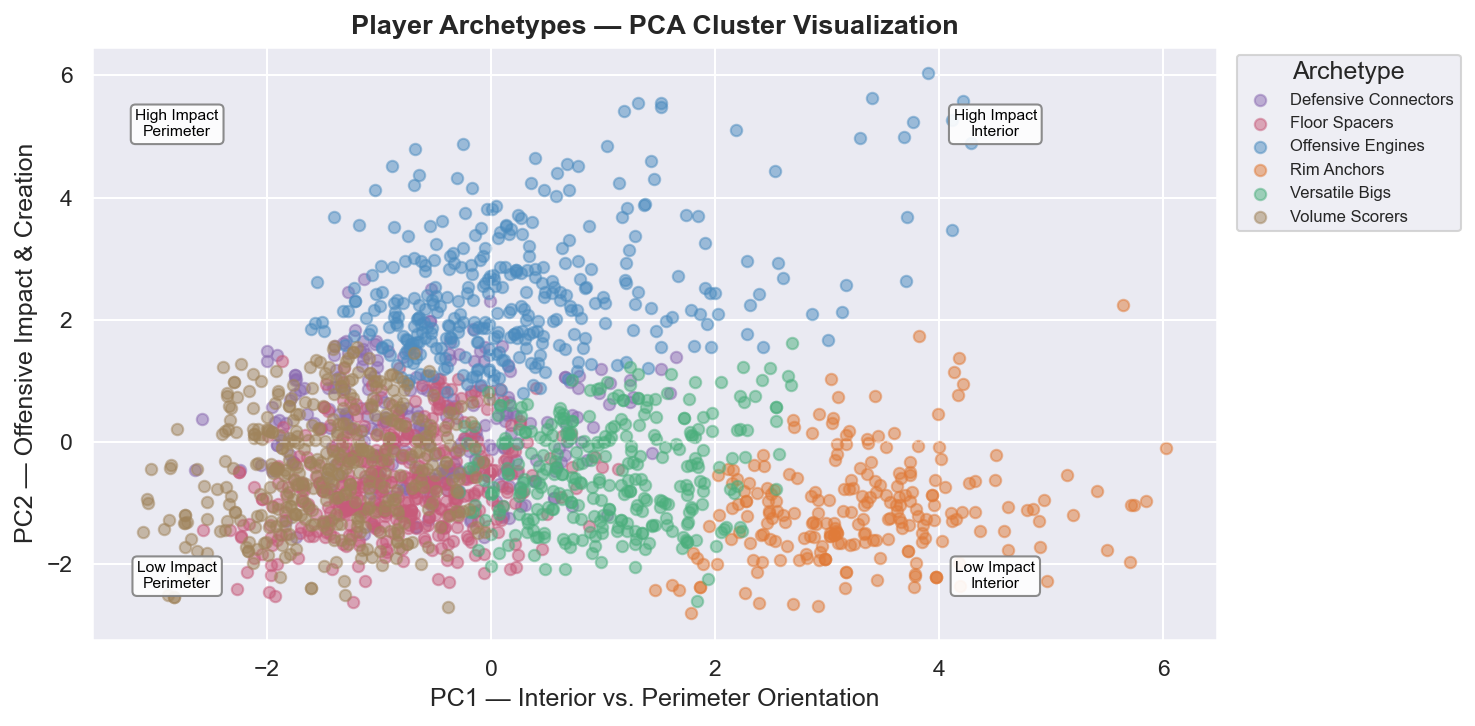

In [13]:
# Chart 8: PCA Cluster Visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
 
# PC1 and PC2 explain 33.0% and 26.2% of variance respectively (59.2% combined)
df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Archetype": master_final.loc[cluster_index, "Archetype"].values
})
 
fig, ax = plt.subplots()
for archetype, group in df_pca.groupby("Archetype"):
    ax.scatter(group["PC1"], group["PC2"], label=archetype,
               color=archetype_colors[archetype], alpha=0.5, s=30)
 
ax.axhline(0, color="white", linewidth=1.0, linestyle="--", alpha=0.4)
ax.axvline(0, color="white", linewidth=1.0, linestyle="--", alpha=0.4)
 
label_style = dict(fontsize=7.5, color="black",
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                             edgecolor="gray", alpha=0.9))
ax.text(4.5,  5.2,  "High Impact\nInterior",   ha="center", va="center", **label_style)
ax.text(-2.8, 5.2,  "High Impact\nPerimeter",  ha="center", va="center", **label_style)
ax.text(4.5,  -2.2, "Low Impact\nInterior",    ha="center", va="center", **label_style)
ax.text(-2.8, -2.2, "Low Impact\nPerimeter",   ha="center", va="center", **label_style)
 
ax.set_title("Player Archetypes — PCA Cluster Visualization",
             fontsize=13, fontweight="bold")
ax.set_xlabel("PC1 — Interior vs. Perimeter Orientation")
ax.set_ylabel("PC2 — Offensive Impact & Creation")
ax.legend(title="Archetype", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("images/pca_clusters.png", bbox_inches="tight")
plt.show()

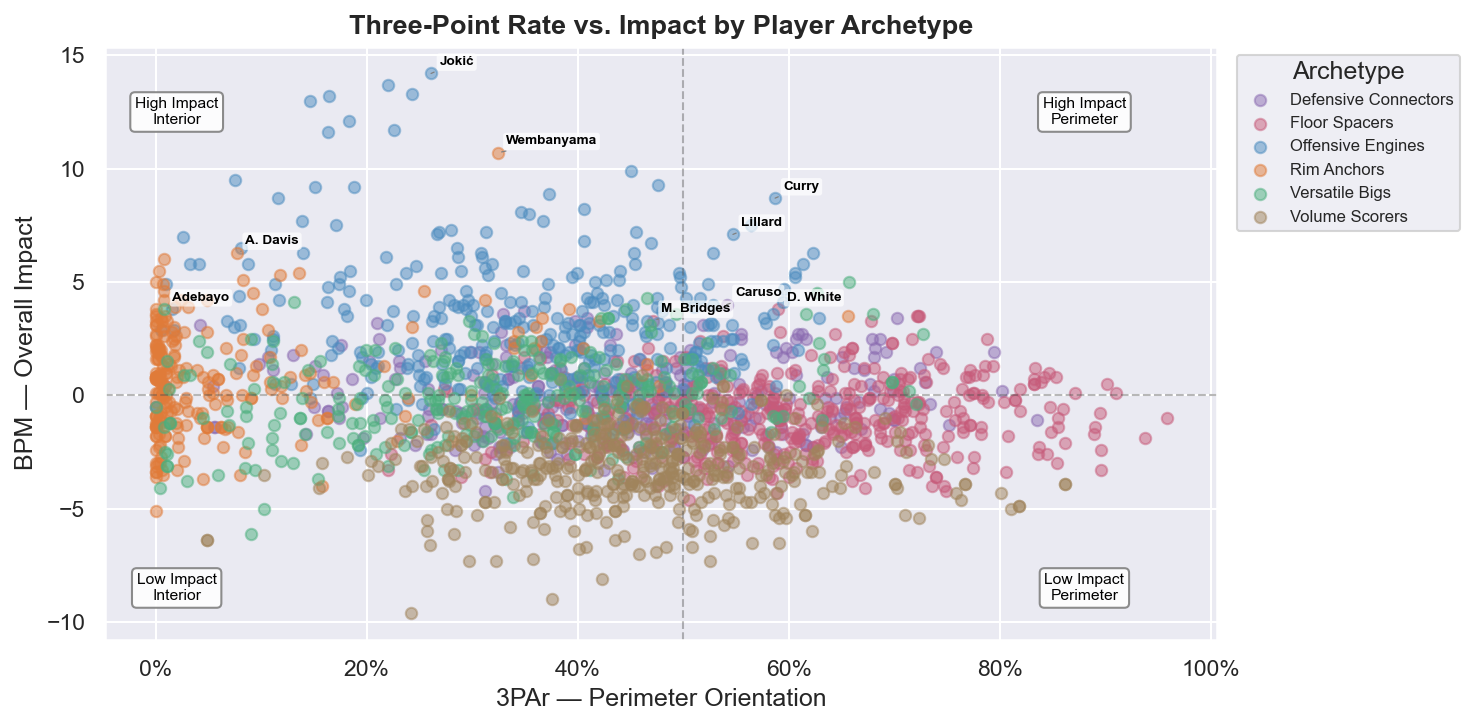

In [14]:
# Chart 9: 3PAr vs. BPM — Archetype Scatter
player_coords = {
    # Offensive Engines
    "Jokić":       (0.261, 14.2),
    "Curry":       (0.587,  8.7),
    "Lillard":     (0.547,  7.1),
    # Rim Anchors
    "Wembanyama":  (0.324, 10.7),
    "A. Davis":    (0.077,  6.3),
    # Floor Spacers
    "D. White":    (0.590,  3.8),
    "M. Bridges":  (0.471,  3.3),
    # Defensive Connectors
    "Caruso":      (0.541,  4.0),
    # Versatile Bigs
    "Adebayo":     (0.008,  3.8),
}
 
fig, ax = plt.subplots()
for archetype, group in master_final.groupby("Archetype"):
    ax.scatter(group["3PAr"], group["BPM"], label=archetype,
               color=archetype_colors[archetype], alpha=0.5, s=30)
 
ax.axhline(0,   color="#4D4D4D", linewidth=1.0, linestyle="--", alpha=0.4)
ax.axvline(0.5, color="#4D4D4D", linewidth=1.0, linestyle="--", alpha=0.4)
 
for label_text, (x, y) in player_coords.items():
    ax.annotate(label_text, xy=(x, y),
                xytext=(4, 4), textcoords="offset points",
                fontsize=6.5, fontweight="bold", color="black",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                          edgecolor="none", alpha=0.7),
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.6))
 
ax.text(0.88,  12.5,  "High Impact\nPerimeter", fontsize=7.5, color="black",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9))
ax.text(0.02,  12.5,  "High Impact\nInterior",  fontsize=7.5, color="black",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9))
ax.text(0.88, -8.5,  "Low Impact\nPerimeter",  fontsize=7.5, color="black",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9))
ax.text(0.02, -8.5,  "Low Impact\nInterior",   fontsize=7.5, color="black",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9))
 
ax.set_title("Three-Point Rate vs. Impact by Player Archetype",
             fontsize=13, fontweight="bold")
ax.set_xlabel("3PAr — Perimeter Orientation")
ax.set_ylabel("BPM — Overall Impact")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(title="Archetype", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("images/archetype_3par_bpm.png", bbox_inches="tight")
plt.show()

## Section 3 — Contract Value & Market Efficiency

Ridge regression model predicting fair market salary (as % of cap) based on on-court performance. Comparing predicted vs. actual salary to surface undervalued and overvalued players across the league.

In [15]:
# Feature selection and train/test split
reg_features = ["PER", "TS%", "WS/48", "BPM", "VORP", "USG%", "MP_adv", "Age_adv"]
 
df_reg = master_final[master_final["MP_adv"] >= 500].copy()
df_reg = df_reg[reg_features + ["Cap_Pct", "Player", "season", "Archetype"]].dropna()
 
X = df_reg[reg_features]
y = df_reg["Cap_Pct"]
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled  = scaler_reg.transform(X_test)
 
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")

Training samples: 1,654
Test samples:     414


In [16]:
# Fit Ridge regression and evaluate
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
 
y_pred = ridge.predict(X_test_scaled)
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
 
print(f"R² Score: {r2:.3f}")
print(f"MAE:      {mae:.4f} ({mae*100:.2f}% of cap, ~${mae*141:.1f}M at current cap)")

R² Score: 0.574
MAE:      0.0441 (4.41% of cap, ~$6.2M at current cap)


In [17]:
# Generate predictions for all eligible players
df_reg["Predicted_Cap_Pct"] = ridge.predict(scaler_reg.transform(X))
df_reg["Delta"]              = df_reg["Predicted_Cap_Pct"] - df_reg["Cap_Pct"]
 
# Convert to dollar values using season cap figures
cap_by_season_m = {
    2021: 112.4, 2022: 119.9, 2023: 123.7,
    2024: 136.0, 2025: 141.0, 2026: 146.0
}
 
df_reg["Cap_Value_M"]        = df_reg["season"].map(cap_by_season_m)
df_reg["Actual_Salary_M"]    = df_reg["Cap_Pct"]           * df_reg["Cap_Value_M"]
df_reg["Predicted_Salary_M"] = df_reg["Predicted_Cap_Pct"] * df_reg["Cap_Value_M"]
df_reg["Delta_M"]            = df_reg["Predicted_Salary_M"] - df_reg["Actual_Salary_M"]
 
top_undervalued = df_reg.nlargest(10, "Delta").copy()
top_overvalued  = df_reg.nsmallest(10, "Delta").copy()
 
for df in [top_undervalued, top_overvalued]:
    df["Label"] = df["Player"] + " '" + df["season"].astype(str).str[-2:]

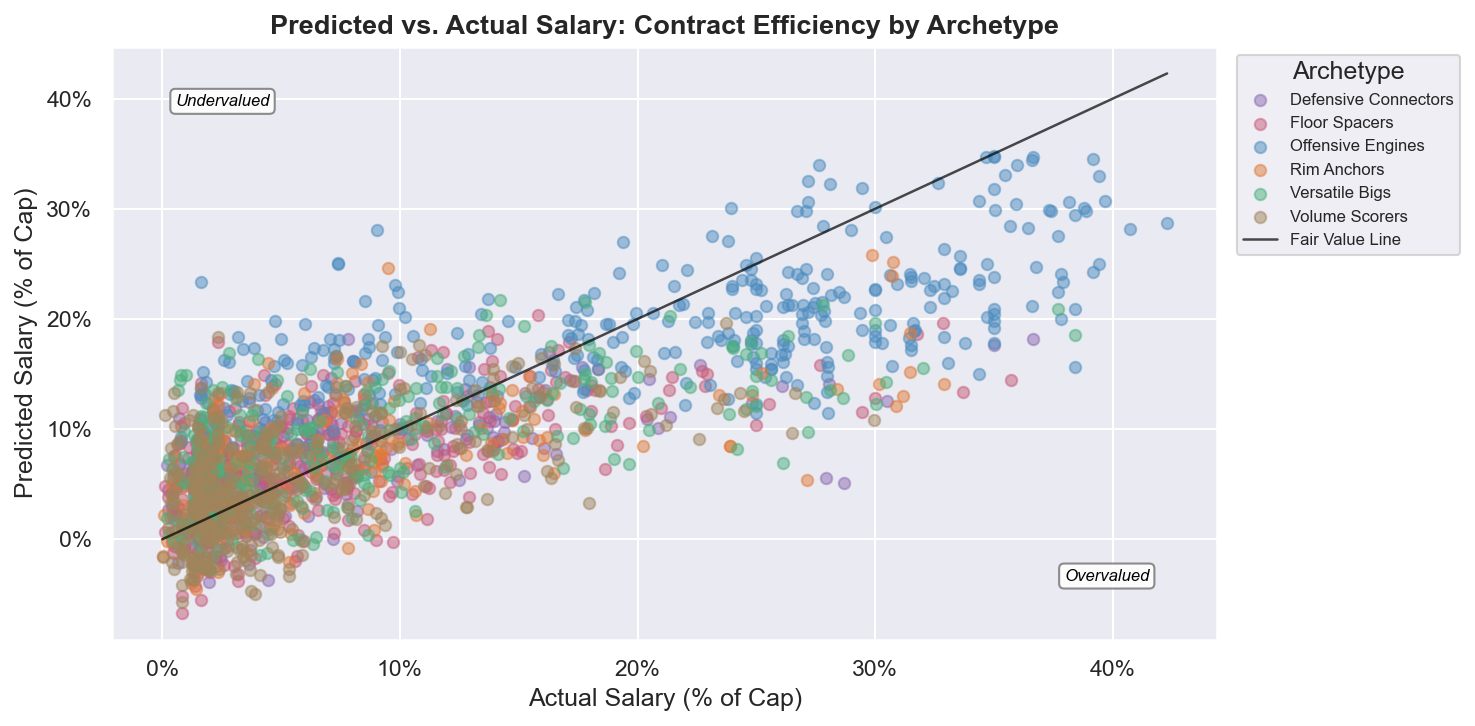

In [18]:
# Chart 10: Predicted vs. Actual Salary
fig, ax = plt.subplots()
for archetype, group in df_reg.groupby("Archetype"):
    ax.scatter(group["Cap_Pct"], group["Predicted_Cap_Pct"],
               color=archetype_colors[archetype], alpha=0.5, s=30, label=archetype)
 
max_val = max(df_reg["Cap_Pct"].max(), df_reg["Predicted_Cap_Pct"].max())
ax.plot([0, max_val], [0, max_val], color="black", linewidth=1.2,
        alpha=0.7, label="Fair Value Line")
 
ax.set_title("Predicted vs. Actual Salary: Contract Efficiency by Archetype",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Actual Salary (% of Cap)")
ax.set_ylabel("Predicted Salary (% of Cap)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(title="Archetype", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.text(0.9, 0.1, "Overvalued",
        transform=ax.transAxes, fontsize=8, color="black",
        ha="center", style="italic",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9))
ax.text(0.1, 0.9, "Undervalued",
        transform=ax.transAxes, fontsize=8, color="black",
        ha="center", style="italic",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9))
plt.tight_layout()
plt.savefig("images/predicted_vs_actual.png", bbox_inches="tight")
plt.show()

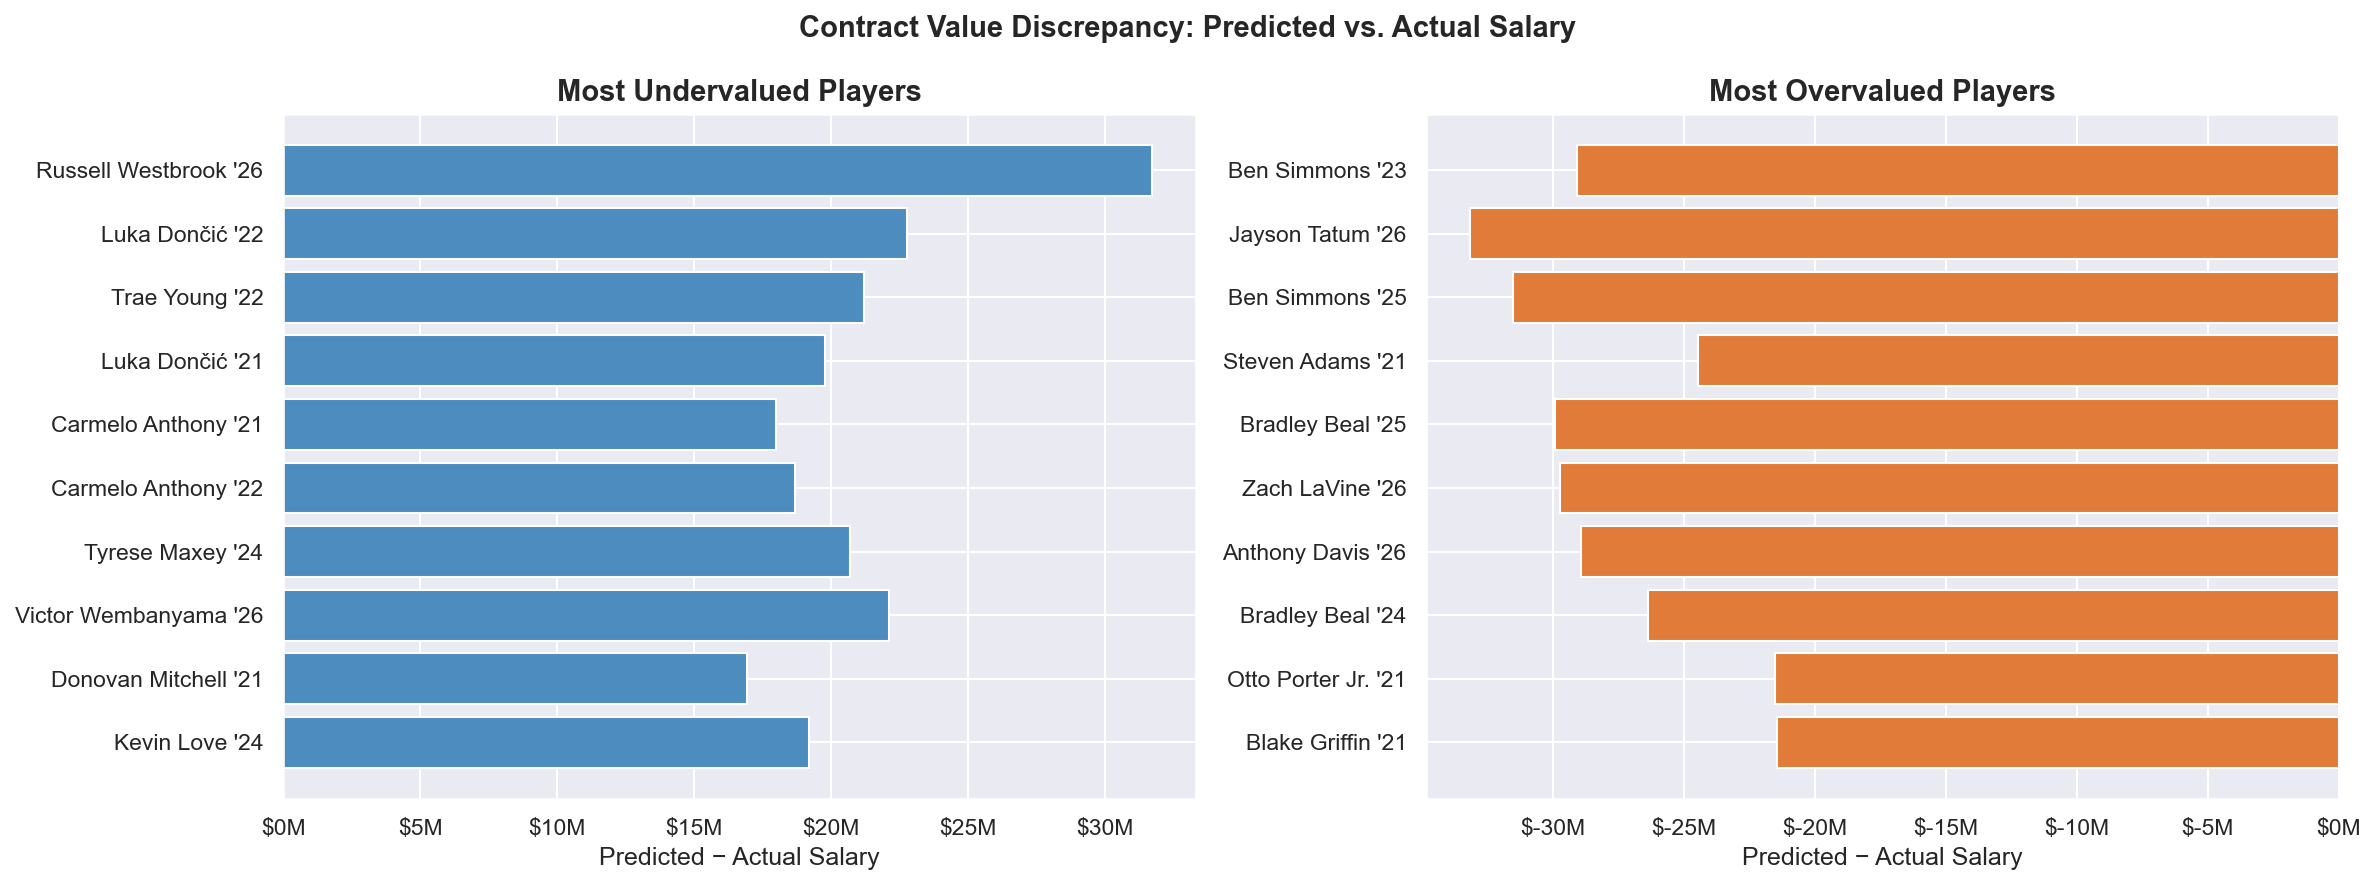

In [19]:
# Chart 11: Contract Value Discrepancy: Top Undervalued & Overvalued
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)
 
axes[0].barh(top_undervalued["Label"], top_undervalued["Delta_M"], color="#4C8CBF")
axes[0].set_title("Most Undervalued Players", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Predicted − Actual Salary")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.0f}M"))
axes[0].invert_yaxis()
 
axes[1].barh(top_overvalued["Label"], top_overvalued["Delta_M"], color="#E07B39")
axes[1].set_title("Most Overvalued Players", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Predicted − Actual Salary")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.0f}M"))
axes[1].invert_yaxis()
 
fig.suptitle("Contract Value Discrepancy: Predicted vs. Actual Salary",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("images/contract_value_discrepancy.png", dpi=150, bbox_inches="tight")
plt.show()

**Model Note:** Russell Westbrook ('26) and Carmelo Anthony ('21, '22) appear among the most undervalued due to veteran minimum salaries paired with historically high usage rates. These cases are flagged and excluded from actionable roster recommendations.

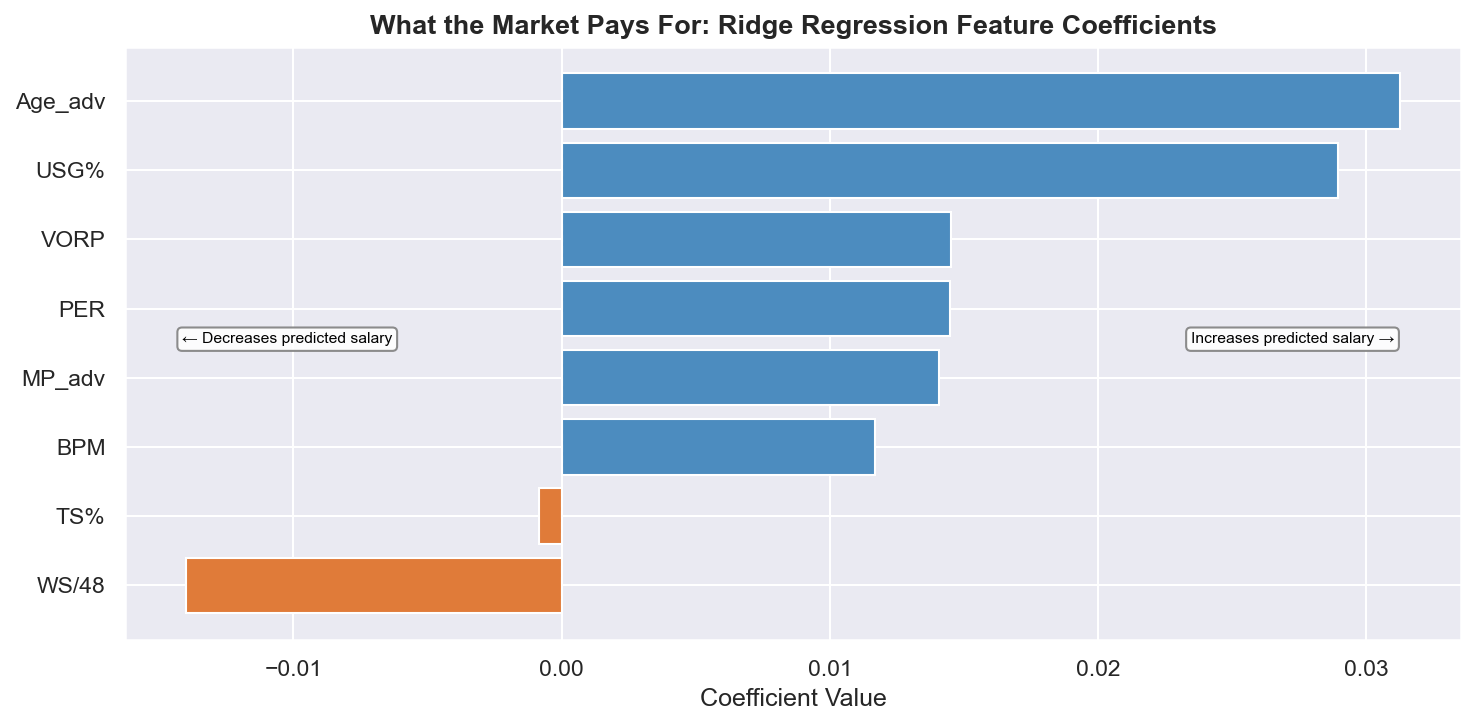

In [20]:
# Chart 12: Ridge Regression Feature Coefficients
coefficients = pd.Series(ridge.coef_, index=reg_features).sort_values()
 
fig, ax = plt.subplots()
colors = ["#E07B39" if c < 0 else "#4C8CBF" for c in coefficients]
ax.barh(coefficients.index, coefficients.values, color=colors)
ax.axvline(0, color="white", linewidth=1.0, linestyle="--", alpha=0.6)
ax.set_title("What the Market Pays For: Ridge Regression Feature Coefficients",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Coefficient Value")
 
# Add positive/negative labels
ax.text(0.2, 0.5, "← Decreases predicted salary",
        transform=ax.transAxes, ha="right", fontsize=7.5, color="black",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9))
ax.text(0.95, 0.5, "Increases predicted salary →",
        transform=ax.transAxes, ha="right", fontsize=7.5, color="black",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9))
 
plt.tight_layout()
plt.savefig("images/feature_coefficients.png")
plt.show()

## Section 4 — Breakout Candidate Identification

Random Forest classifier trained to identify players likely to improve BPM by +2.0 or more from one season to the next. Applied to 2026 data to generate a 2027 breakout watchlist.

In [21]:
# Engineer year-over-year BPM delta and binary breakout target
master_sorted = master_final.sort_values(["Player", "season"]).copy()
master_sorted["BPM_next"]  = master_sorted.groupby("Player")["BPM"].shift(-1)
master_sorted["BPM_delta"] = master_sorted["BPM_next"] - master_sorted["BPM"]
 
df_clf = master_sorted.dropna(subset=["BPM_next"]).copy()
df_clf = df_clf[
    (df_clf["MP_adv"]  >= 500) &
    (df_clf["Age_adv"] <= 27)  &
    (df_clf["BPM"]     <  4)
].copy()
 
df_clf["Breakout"] = (df_clf["BPM_delta"] >= 2.0).astype(int)
 
print(f"Eligible player-seasons: {len(df_clf):,}")
print(f"Breakout cases:          {df_clf['Breakout'].sum()} ({df_clf['Breakout'].mean():.1%})")
print(f"Non-breakout cases:      {(df_clf['Breakout'] == 0).sum()}")

Eligible player-seasons: 897
Breakout cases:          164 (18.3%)
Non-breakout cases:      733


In [22]:
# Train Random Forest classifier
clf_features = ["Age_adv", "BPM", "MP_adv", "USG%", "TS%"]
 
X_clf = df_clf[clf_features]
y_clf = df_clf["Breakout"]
 
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
 
rf = RandomForestClassifier(n_estimators=200, random_state=42,
                            class_weight="balanced", min_samples_leaf=2,
                            max_depth=6)
rf.fit(X_train_clf, y_train_clf)
 
# Apply 0.3 decision threshold — optimized for recall over precision
# Missing a breakout is more costly than a false positive for a front office
y_prob_clf  = rf.predict_proba(X_test_clf)[:, 1]
y_pred_final = (y_prob_clf >= 0.3).astype(int)
 
print("── Model Performance (0.3 Decision Threshold) ──")
print(classification_report(y_test_clf, y_pred_final,
                             target_names=["No Breakout", "Breakout"]))

── Model Performance (0.3 Decision Threshold) ──
              precision    recall  f1-score   support

 No Breakout       0.85      0.39      0.53       147
    Breakout       0.20      0.70      0.32        33

    accuracy                           0.44       180
   macro avg       0.53      0.54      0.42       180
weighted avg       0.73      0.44      0.49       180



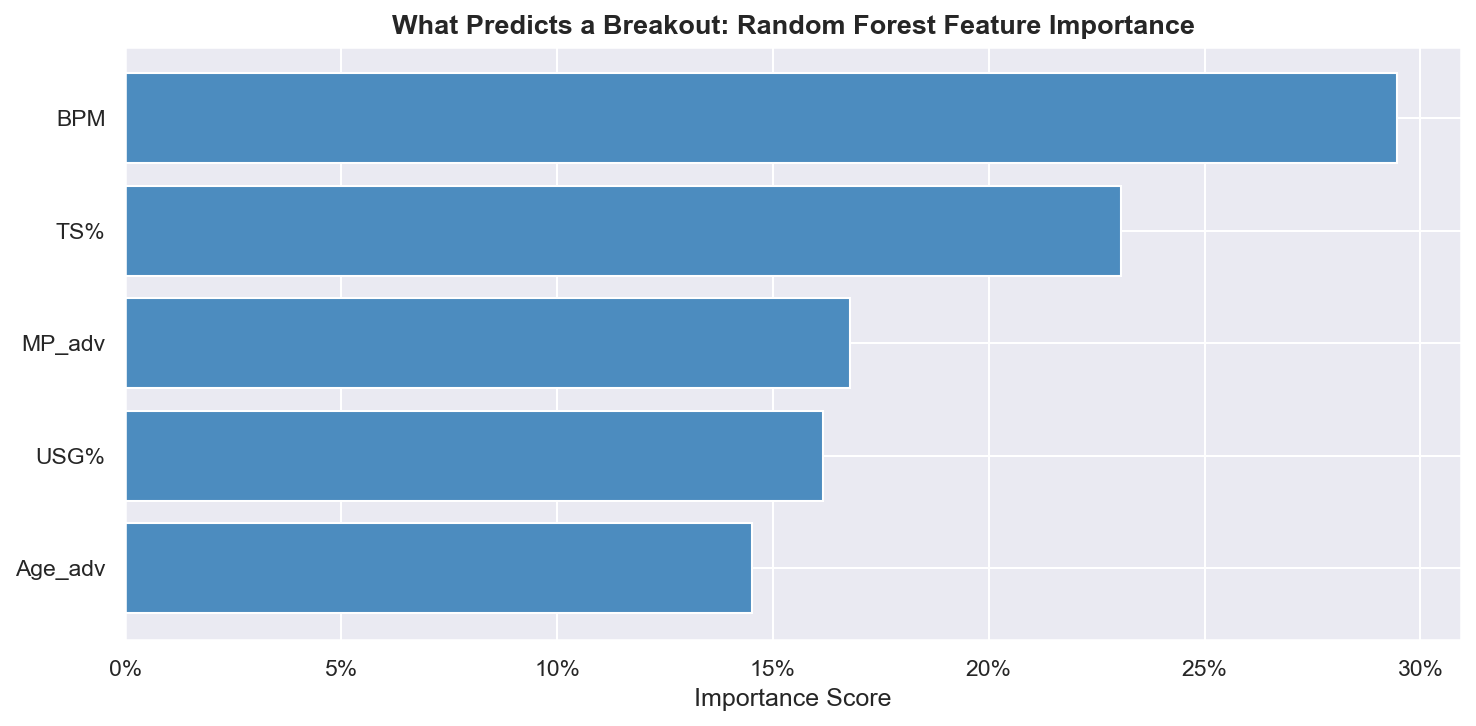

In [23]:
# Chart 13: Feature Importance — Breakout Prediction
feature_importance = pd.Series(rf.feature_importances_, index=clf_features).sort_values()
 
fig, ax = plt.subplots()
ax.barh(feature_importance.index, feature_importance.values, color="#4C8CBF")
ax.set_title("What Predicts a Breakout: Random Forest Feature Importance",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig("images/breakout_feature_importance.png")
plt.show()

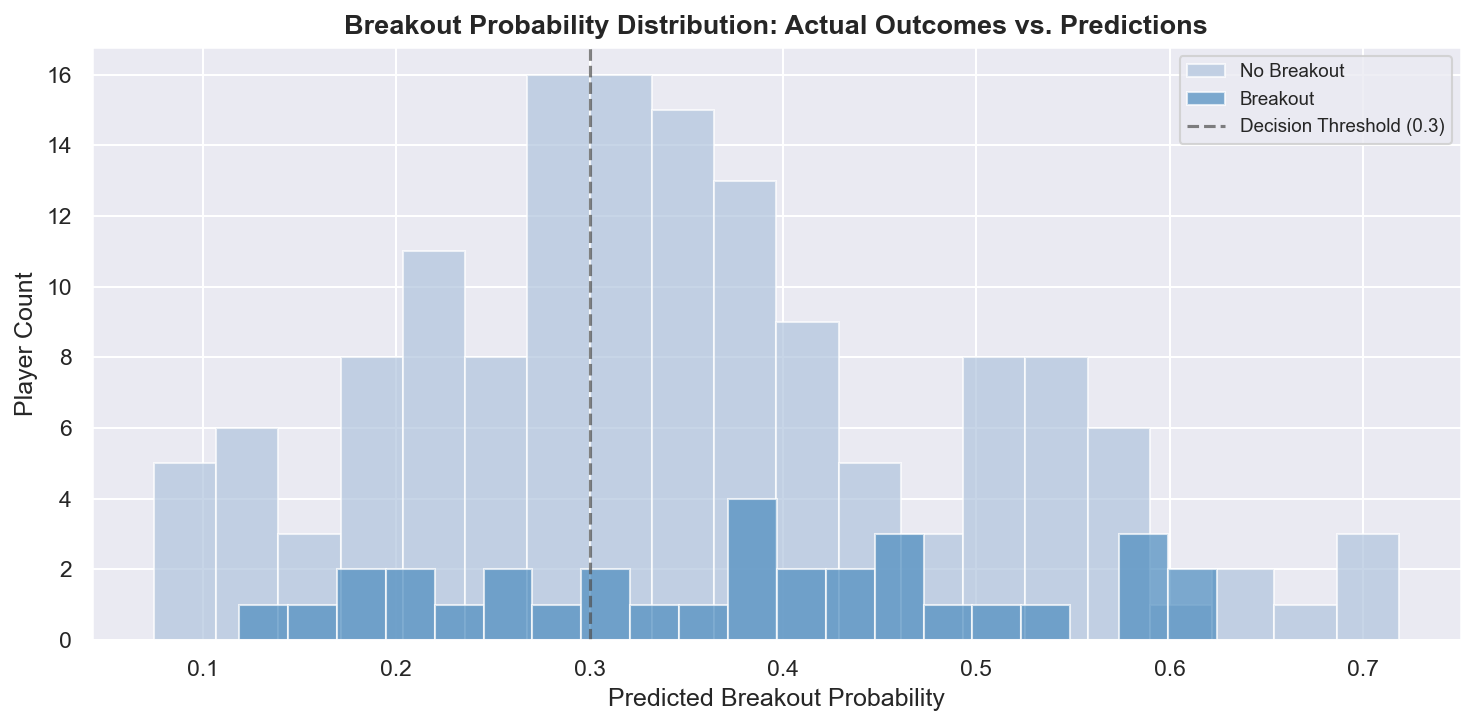

In [24]:
# Chart 14: Predicted Breakout Probability Distribution
df_probs = pd.DataFrame({
    "Probability": y_prob_clf,
    "Outcome": y_test_clf.map({0: "No Breakout", 1: "Breakout"}).values
})
 
fig, ax = plt.subplots()
for outcome, color in [("No Breakout", "#B0C4DE"), ("Breakout", "#4C8CBF")]:
    subset = df_probs[df_probs["Outcome"] == outcome]
    ax.hist(subset["Probability"], bins=20, alpha=0.7, label=outcome, color=color)
 
ax.axvline(0.3, color="#4D4D4D", linewidth=1.5, linestyle="--", alpha=0.7,
           label="Decision Threshold (0.3)")
ax.set_title("Breakout Probability Distribution: Actual Outcomes vs. Predictions",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Breakout Probability")
ax.set_ylabel("Player Count")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("images/breakout_probability_dist.png")
plt.show()

In [25]:
# Model Validation — MIP Finalist Backtesting
 
mip_finalists = {
    2026: ["Nickeil Alexander-Walker", "Deni Avdija", "Jalen Duren"],
    2025: ["Cade Cunningham", "Dyson Daniels", "Ivica Zubac"],
    2024: ["Tyrese Maxey", "Coby White", "Alperen Sengun"],
    2023: ["Lauri Markkanen", "Shai Gilgeous-Alexander", "Jalen Brunson"],
    2022: ["Ja Morant", "Darius Garland", "Dejounte Murray"]
}

print("── MIP Finalist Backtesting Results ──\n")
for year, players in mip_finalists.items():
    prior_season = year - 1
    print(f"{year} MIP Finalists — model applied to previous season:")
    subset = master_final[
        (master_final["Player"].isin(players)) &
        (master_final["season"] == prior_season)
    ][["Player", "season", "BPM", "Age_adv", "MP_adv", "USG%", "TS%"]].copy()

    eligible = subset[
        (subset["MP_adv"]  >= 500) &
        (subset["Age_adv"] <= 27)  &
        (subset["BPM"]     <  4)
    ].dropna(subset=clf_features)

    if len(eligible) > 0:
        eligible = eligible.copy()
        eligible["Breakout_Prob"] = rf.predict_proba(eligible[clf_features])[:, 1]
        eligible["Flagged"] = eligible["Breakout_Prob"].apply(
            lambda p: "✓" if p >= 0.3 else "✗")
        eligible["Flagged"] = eligible["Flagged"].str.center(6)
        print(eligible[["Player", "BPM", "Age_adv", "Breakout_Prob", "Flagged"]]
              .to_string(index=False))
    else:
        print("  No eligible players (filtered by age/minutes/BPM thresholds)")
    print()

── MIP Finalist Backtesting Results ──

2026 MIP Finalists — model applied to previous season:
     Player  BPM  Age_adv  Breakout_Prob Flagged
Deni Avdija  2.1     24.0       0.351158    ✓   
Jalen Duren  3.1     21.0       0.157686    ✗   

2025 MIP Finalists — model applied to previous season:
         Player  BPM  Age_adv  Breakout_Prob Flagged
Cade Cunningham  0.3     22.0       0.562286    ✓   
    Ivica Zubac  0.8     26.0       0.365525    ✓   
  Dyson Daniels  0.6     20.0       0.364912    ✓   

2024 MIP Finalists — model applied to previous season:
      Player  BPM  Age_adv  Breakout_Prob Flagged
Tyrese Maxey  0.6     22.0       0.401134    ✓   
  Coby White -0.8     22.0       0.354599    ✓   

2023 MIP Finalists — model applied to previous season:
         Player  BPM  Age_adv  Breakout_Prob Flagged
  Jalen Brunson  0.9     25.0       0.431721    ✓   
Lauri Markkanen  0.4     24.0       0.345313    ✓   

2022 MIP Finalists — model applied to previous season:
         Play

### Eligibility Notes

Three finalists were excluded from backtesting by design constraints rather than
model failure:

- **Shai Gilgeous-Alexander (2023)** — prior BPM exceeded the +4.0 threshold,
  indicating he was already an established high-impact player before his MIP
  finalist season.
- **Alperen Sengun (2024)** — same reason; his 2023 BPM was already above +4.0,
  placing him outside the realistic breakout candidate pool the model targets.
- **Nickeil Alexander-Walker (2026)** — exceeded the age threshold of 27 in his
  prior season, disqualifying him from the model's developmental player focus.

In all three cases the exclusion reflects intentional model design — the classifier
is built to identify emerging players with untapped upside, not established stars
or veterans. Their absence from the backtesting results is not a miss.

In [26]:
# Generate 2027 Breakout Watchlist from 2026 season data
df_2026 = master_final[
    (master_final["season"] == 2026) &
    (master_final["MP_adv"]  >= 500) &
    (master_final["Age_adv"] <= 27)  &
    (master_final["BPM"]     <  4)   &
    (master_final["BPM"]     >= -4.0)
].copy().dropna(subset=clf_features).drop_duplicates("Player")
 
df_2026["Breakout_Prob"] = rf.predict_proba(df_2026[clf_features])[:, 1]

In [27]:
# Cross-reference with Section 3 undervalued players (buy-low watchlist)
undervalued = (df_reg[df_reg["Delta"] > 0]
               .sort_values(["Player", "season"], ascending=[True, False])
               .groupby("Player")
               .head(2)
               .sort_values("Delta_M", ascending=False)
               .drop_duplicates("Player", keep="first")
               [["Player", "Archetype", "season", "Actual_Salary_M",
                 "Predicted_Salary_M", "Delta_M"]]
               .copy())
 
breakout_probs = df_2026[["Player", "Breakout_Prob"]].copy()
 
summary = (undervalued.merge(breakout_probs, on="Player", how="inner")
           .query("Breakout_Prob >= 0.3")
           .sort_values("Breakout_Prob", ascending=False)
           .head(20))
 
print(f"Buy-low candidates identified: {len(summary)}")

Buy-low candidates identified: 20


In [ ]:
# Chart 15: Buy-Low Watchlist — Undervalued Players with Breakout Potential
fig, ax = plt.subplots(figsize=(10, 7), dpi=150)
 
colors = [archetype_colors[a] for a in summary["Archetype"]]
bars   = ax.barh(summary["Player"], summary["Breakout_Prob"],
                 color=colors, alpha=0.85)
 
for bar, (_, row) in zip(bars, summary.iterrows()):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'+${row["Delta_M"]:.1f}M',
            va="center", fontsize=8, color="black")
 
ax.axvline(0.3, color="#4D4D4D", linewidth=1.5, linestyle="--",
           alpha=0.7, label="Decision Threshold (0.3)")
ax.set_title("2027 Buy-Low Watchlist — Breakout Probability & Salary Upside",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Breakout Probability")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlim(0, 0.85)
ax.invert_yaxis()
 
legend_elements = [mpatches.Patch(facecolor=archetype_colors[a], label=a)
                   for a in summary["Archetype"].unique()]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1),
          loc="upper left", fontsize=8, title="Archetype")
 
plt.tight_layout()
plt.savefig("images/buy_low_watchlist.png", bbox_inches="tight")
plt.show()